## Data Exploration and Cleaning

[Mendeley - Steam Games Metadata and Player Reviews](https://data.mendeley.com/datasets/jxy85cr3th/2)

**Sampling**

In [73]:
import pandas as pd
import json
import os
import numpy as np
import csv
from langdetect import detect, LangDetectException
import matplotlib.pyplot as plt

In [ ]:
# Reduce Mendeley games.json to game id and name only
# ALREADY EXIST AS ../cleaned_data/mendeley_id_to_name.json
input_path = '../data/mendeley/games.json'
output_path = '../data/mendeley/games_reduced.json'
with open(input_path, 'r', encoding='utf-8') as f:
    games_data = json.load(f)
reduced_games = {}
for game_id, info in games_data.items():
    if game_id in reduced_games:
        print(f"Duplicate game ID found: {game_id}")
    reduced_games[game_id] = info['name']
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(reduced_games, f, indent=2)

### MapReduce
We want to know imbalance of class labels (positive/negative) of all reviews. Since the dataset is very large, we will use a method called Map Reduce to first gather the data then catagorize them.

In [ ]:
# Will take ~30 minutes
# Create spreadsheet of game files in categories:
# - total reviews
# - positive ratio

all_game_stats  = {}
games_collected = 0
files_created = 0

for game_file in os.listdir('../data/Mendeley/reviews/'):
    game_id = game_file.split('_')[0]    # file name is <id>_<num of reviews>.csv
    with open(os.path.join('../data/Mendeley/reviews/', game_file), 'r', encoding='utf-8') as f:
        game_df = pd.read_csv(f)
    
    total_reviews = len(game_df)
    positive_reviews = sum(1 for _, row in game_df.iterrows() if row['recommend'] == "Recommended")
    pos_ratio = positive_reviews / total_reviews if total_reviews > 0 else 0
    all_game_stats[game_id] = {
        'tot_reviews': total_reviews,
        'pos_reviews': positive_reviews,
        'pos_ratio':  pos_ratio,
    }
    games_collected += 1
    if games_collected % 1000 == 0:
        print(f"Processed {games_collected} games")
    # flush progress every 2400 games
    if games_collected % 2400 == 0:
        with open(f'../data/Mendeley/game_stats/info{files_created}.json', 'w', encoding='utf-8') as f:
                json.dump(all_game_stats, f, indent=2)
        files_created += 1
        all_game_stats = {}

Processed 1000 games
Processed 2000 games
Processed 3000 games
Processed 4000 games
Processed 5000 games
Processed 6000 games
Processed 7000 games
Processed 8000 games
Processed 9000 games
Processed 10000 games
Processed 11000 games
Processed 12000 games
Processed 13000 games
Processed 14000 games
Processed 15000 games
Processed 16000 games
Processed 17000 games
Processed 18000 games
Processed 19000 games
Processed 20000 games
Processed 21000 games
Processed 22000 games
Processed 23000 games


In [ ]:
# record last subset...
with open(f'../data/Mendeley/game_stats/info{files_created}.json', 'w', encoding='utf-8') as f:
            json.dump(all_game_stats, f, indent=2)
print(f"Finalized stats for {games_collected} games")

In [ ]:
# Categorize games by positive ratio

pos_categories = [50, 70, 80, 90, 95, 100]
pos_files = [
    "../cleaned_data/mendeley_ordered_by_pos/pos_0-50.csv",
    "../cleaned_data/mendeley_ordered_by_pos/pos_50-70.csv",
    "../cleaned_data/mendeley_ordered_by_pos/pos_70-80.csv",
    "../cleaned_data/mendeley_ordered_by_pos/pos_80-90.csv",
    "../cleaned_data/mendeley_ordered_by_pos/pos_90-95.csv",
    "../cleaned_data/mendeley_ordered_by_pos/pos_95-100.csv",
]

for info_file in os.listdir('../data/Mendeley/game_stats/'):
    with open(os.path.join('../data/Mendeley/game_stats/', info_file), 'r', encoding='utf-8') as f:
        game_stats = json.load(f)
    pos_opened = []
    for pos_file in pos_files:
        pos_opened.append(open(pos_file, 'a', encoding='utf-8', newline=''))

    for game_id, stats in game_stats.items():
        pos_ratio = stats['pos_ratio'] * 100
        row = {'game_id': game_id}
        row.update(stats)
        if pos_ratio < pos_categories[0]:
            writer = csv.DictWriter(pos_opened[0], fieldnames=row.keys())
            if pos_opened[0].tell() == 0:
                writer.writeheader()
            writer.writerow(row)
        elif pos_ratio < pos_categories[1]:
            writer = csv.DictWriter(pos_opened[1], fieldnames=row.keys())
            if pos_opened[1].tell() == 0:
                writer.writeheader()
            writer.writerow(row)
        elif pos_ratio < pos_categories[2]:
            writer = csv.DictWriter(pos_opened[2], fieldnames=row.keys())
            if pos_opened[2].tell() == 0:
                writer.writeheader()
            writer.writerow(row)
        elif pos_ratio < pos_categories[3]:
            writer = csv.DictWriter(pos_opened[3], fieldnames=row.keys())
            if pos_opened[3].tell() == 0:
                writer.writeheader()
            writer.writerow(row)
        elif pos_ratio < pos_categories[4]:
            writer = csv.DictWriter(pos_opened[4], fieldnames=row.keys())
            if pos_opened[4].tell() == 0:
                writer.writeheader()
            writer.writerow(row)
        else:
            writer = csv.DictWriter(pos_opened[5], fieldnames=row.keys())
            if pos_opened[5].tell() == 0:
                writer.writeheader()
            writer.writerow(row)

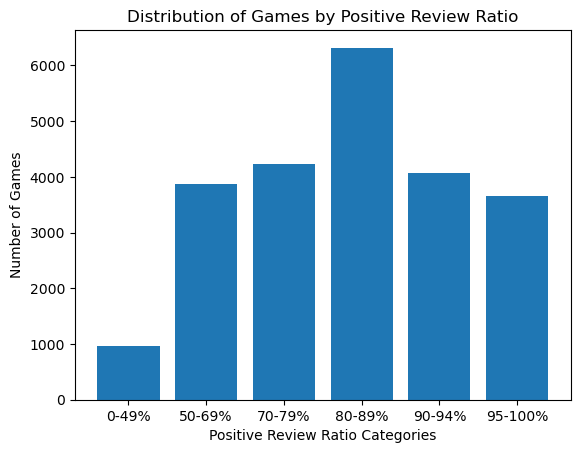

In [79]:
# Plot distribution of positive ratio categories
ratio_labels = ['0-49%', '50-69%', '70-79%', '80-89%', '90-94%', '95-100%']
counts = []
for pos_file in pos_files:
    with open(pos_file, 'r', encoding='utf-8') as f:
        df = pd.read_csv(f)
    counts.append(len(df))

plt.bar(ratio_labels, counts)
plt.xlabel('Positive Review Ratio Categories')
plt.ylabel('Number of Games')
plt.title('Distribution of Games by Positive Review Ratio')
plt.show()

MapReduce results show that most game have more positive reviews than negative reviews. 

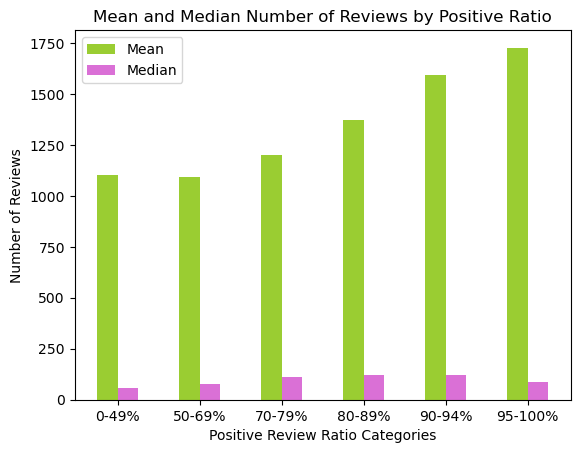

In [81]:
# see mean and median review counts in each category
mean_counts = []
median_counts = []
for pos_file in pos_files:
    with open(pos_file, 'r', encoding='utf-8') as f:
        df = pd.read_csv(f)
    mean_counts.append(df['tot_reviews'].mean())
    median_counts.append(df['tot_reviews'].median())

bar_width = 0.25
x = np.arange(len(ratio_labels))
plt.bar(x, mean_counts, width=bar_width, label='Mean', color='yellowgreen')
plt.bar(x + bar_width, median_counts, width=bar_width, label='Median', color='orchid')

plt.xlabel('Positive Review Ratio Categories')
plt.ylabel('Number of Reviews')
plt.title('Mean and Median Number of Reviews by Positive Ratio')
plt.legend()
plt.xticks(x + bar_width / 2, ratio_labels)
plt.show()

The more popular a game is, the higher than rating.

In [ ]:
# Record game id to number of review based on file naming
# ALREADY EXIST AS ../cleaned_data/mendeley_id_to_review_num.csv
num_review_data = [['id', 'num_reviews']]

for game_file in os.listdir('../data/Mendeley/reviews/'):
    combined_name = game_file.strip('.csv')
    game_id, num_reviews = combined_name.split('_')
    num_review_data.append([game_id, num_reviews])

with open('../data/Mendeley/num_reviews.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(num_review_data)

Most reviews: 336460
Least reviews: 26
Average reviews: 1377.608
Median reviews: 100.0


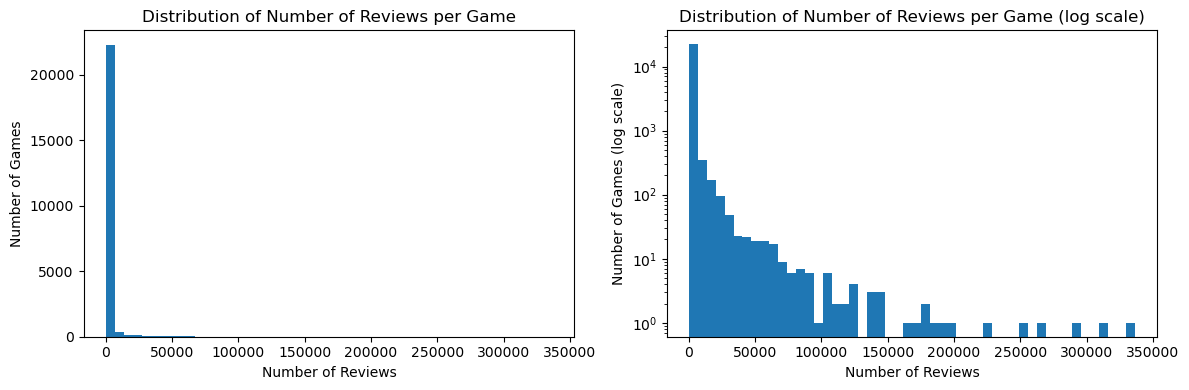

In [25]:
# Graph distribution of number of reviews
with open('../data/Mendeley/game_stats/num_reviews.csv', 'r', encoding='utf-8') as f:
    num_reviews_df = pd.read_csv(f)
print(f"Most reviews: {num_reviews_df['num_reviews'].max()}")
print(f"Least reviews: {num_reviews_df['num_reviews'].min()}")
print(f"Average reviews: {num_reviews_df['num_reviews'].mean():.3f}")
print(f"Median reviews: {num_reviews_df['num_reviews'].median()}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(num_reviews_df['num_reviews'], bins=50, log=True)
axes[0].set_yscale("linear")
axes[0].set_title('Distribution of Number of Reviews per Game')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Games')
axes[1].hist(num_reviews_df['num_reviews'], bins=50)
axes[1].set_yscale("log")
axes[1].set_title('Distribution of Number of Reviews per Game (log scale)')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Games (log scale)')

plt.tight_layout()
plt.show()

In [60]:
# ========== Sample Generation ==========
def sample_games_by_review_count(min_reviews, max_reviews, sample_size, seed=None) -> list[str]:
    # Given a range of review counts, sample a number of games within that range.
    with open('../cleaned_data/mendeley_id_to_review_num.csv', 'r', encoding='utf-8') as f:
        num_reviews_df = pd.read_csv(f)
    filtered_games = num_reviews_df[
        (num_reviews_df['num_reviews'] >= min_reviews) &
        (num_reviews_df['num_reviews'] <= max_reviews)
    ]
    if seed:
        sampled_games = filtered_games.sample(n=sample_size, random_state=seed)
    else:
        sampled_games = filtered_games.sample(n=sample_size)
    csv_file_paths = sampled_games['id'].astype(str) + '_'+ sampled_games['num_reviews'].astype(str) + '.csv'
    return csv_file_paths.tolist()

def resolve_id_to_name(game_id: str) -> str:
    with open('../cleaned_data/mendeley_id_to_name.json', 'r', encoding='utf-8') as f:
        games_id_to_name = json.load(f)
    return games_id_to_name.get(game_id, "Unknown Game")

# Sanity test
sampled_files = sample_games_by_review_count(100000, 300000, 5)
print("CSV file format <game_id>_<num_reviews>.csv")
print("Sampled game files:")
for file_name in sampled_files:
    game_name = resolve_id_to_name(file_name.split('_')[0])
    print(f"{file_name} ({game_name})")

CSV file format <game_id>_<num_reviews>.csv
Sampled game files:
2050650_104398.csv (Resident Evil 4)
304390_146029.csv (FOR HONOR™)
1599340_201079.csv (Lost Ark)
1817070_101951.csv (Marvel’s Spider-Man Remastered)
2073850_140640.csv (THE FINALS)
